## Cell 1 — Install

In [1]:
!pip install easyocr transformers sentencepiece 

## Cell 2 — Imports

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import easyocr
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Cell 3 — Load EasyOCR Readers

In [3]:
reader_hi = easyocr.Reader(['hi', 'en'], gpu=True)
reader_bn = easyocr.Reader(['bn', 'en'], gpu=True)
print("EasyOCR readers ready.")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR readers ready.


## Cell 4 — Load Translation Models

In [4]:
hi_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-hi-en", timeout=60)
hi_model     = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-hi-en")

bn_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-bn-en", timeout=60)
bn_model     = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-bn-en")

print("Translation models ready.")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/309M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Translation models ready.


## Cell 5 — CRNN: Define, Train, Save Weights

In [5]:
# ── Dataset paths ─────────────────────────────────────────────────────────────
deva_base   = "/kaggle/input/datasets/ashokpant/devanagari-character-dataset/nhcd/nhcd"
bangla_base = "/kaggle/input/datasets/asefjamilajwad2/banglalekha-isolated/BanglaLekha-Isolated/Images"

# ── Load balanced samples ─────────────────────────────────────────────────────
def get_balanced_samples(base_path, ext, samples_per_class=50):
    class_images = defaultdict(list)
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(ext):
                class_name = os.path.basename(root)
                class_images[class_name].append(os.path.join(root, file))
    selected = []
    for class_name, images in class_images.items():
        random.shuffle(images)
        for img_path in images[:samples_per_class]:
            selected.append((img_path, class_name))
    return selected

hindi_data   = get_balanced_samples(deva_base,   '.jpg', 50)
bengali_data = get_balanced_samples(bangla_base, '.png', 50)
all_data     = hindi_data + bengali_data

all_labels  = sorted(set([label for _, label in all_data]))
label2idx   = {label: idx for idx, label in enumerate(all_labels)}
idx2label   = {idx: label for label, idx in label2idx.items()}
num_classes = len(all_labels)

hindi_labels   = set([label for _, label in hindi_data])
bengali_labels = set([label for _, label in bengali_data])

print(f"Hindi samples: {len(hindi_data)} | Bengali samples: {len(bengali_data)}")
print(f"Total: {len(all_data)} | Classes: {num_classes}")

# ── Transform ─────────────────────────────────────────────────────────────────
crnn_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((32, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ── Dataset class ─────────────────────────────────────────────────────────────
class IndicDataset(Dataset):
    def __init__(self, data, transform):
        self.data      = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        return img, label2idx[label]

dataset    = IndicDataset(all_data, crnn_transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Batches per epoch: {len(dataloader)}")

# ── CRNN Architecture ─────────────────────────────────────────────────────────
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
        )
        self.rnn = nn.LSTM(128 * 4, 256, batch_first=True, bidirectional=True)
        self.fc  = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        b, c, h, w = x.size()
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(b, w, c * h)
        x, _ = self.rnn(x)
        x = self.fc(x[:, -1, :])
        return x

# ── Train ─────────────────────────────────────────────────────────────────────
crnn_model = CRNN(num_classes).to(device)
optimizer  = optim.Adam(crnn_model.parameters(), lr=0.001)
criterion  = nn.CrossEntropyLoss()

for epoch in range(10):
    crnn_model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in dataloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = crnn_model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    acc = 100. * correct / total
    print(f"Epoch {epoch+1}/10 | Loss: {total_loss/len(dataloader):.4f} | Accuracy: {acc:.2f}%")

torch.save(crnn_model.state_dict(), '/kaggle/working/indic_crnn_finetuned.pth')
print("\n✅ Weights saved to /kaggle/working/indic_crnn_finetuned.pth")

Hindi samples: 1850 | Bengali samples: 4200
Total: 6050 | Classes: 94
Batches per epoch: 190
Epoch 1/10 | Loss: 4.0201 | Accuracy: 5.31%
Epoch 2/10 | Loss: 3.0933 | Accuracy: 20.02%
Epoch 3/10 | Loss: 2.4547 | Accuracy: 33.55%
Epoch 4/10 | Loss: 1.9582 | Accuracy: 46.51%
Epoch 5/10 | Loss: 1.5866 | Accuracy: 56.63%
Epoch 6/10 | Loss: 1.2515 | Accuracy: 66.58%
Epoch 7/10 | Loss: 0.9855 | Accuracy: 74.20%
Epoch 8/10 | Loss: 0.7375 | Accuracy: 81.82%
Epoch 9/10 | Loss: 0.5322 | Accuracy: 87.93%
Epoch 10/10 | Loss: 0.4042 | Accuracy: 91.60%

✅ Weights saved to /kaggle/working/indic_crnn_finetuned.pth


## Cell 6 — Load CRNN Weights + Script Validator

In [6]:
# Load saved weights into eval mode
crnn_model.load_state_dict(
    torch.load('/kaggle/working/indic_crnn_finetuned.pth', map_location=device)
)
crnn_model.eval()
print(f"CRNN loaded on {device}")

# Script label mapper
def idx_to_script(idx):
    label = idx2label[idx]
    if label in bengali_labels:
        return 'bn'
    return 'hi'

# CRNN-based script validator for low-confidence crops
def crnn_detect_script(crop_bgr):
    """
    Splits a text crop into character-sized patches,
    runs each through CRNN, majority vote decides script.
    Returns: 'hi' or 'bn'
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    patch_w     = max(32, h)
    num_patches = max(1, w // patch_w)
    votes = {'hi': 0, 'bn': 0}

    for i in range(num_patches):
        x_start = i * patch_w
        x_end   = min(x_start + patch_w, w)
        patch   = gray[:, x_start:x_end]
        if patch.shape[1] < 8:
            continue
        pil_patch = Image.fromarray(patch).convert('RGB')
        tensor    = crnn_transform(pil_patch).unsqueeze(0).to(device)
        with torch.no_grad():
            output   = crnn_model(tensor)
            pred_idx = output.argmax(dim=1).item()
        votes[idx_to_script(pred_idx)] += 1

    return 'bn' if votes['bn'] >= votes['hi'] else 'hi'

print("CRNN script validator ready.")

CRNN loaded on cuda
CRNN script validator ready.


## Cell 7 — Helper Functions

In [7]:
# =============================================================================
# CELL 13 — Helper Functions (FIXED)
# Changes:
#   1. Tighter confidence gates: >0.80 accept, 0.55-0.80 retry, <0.55 reject
#   2. Unicode script detection is now PRIMARY lang decider (not tiebreaker)
#   3. Preprocessing (CLAHE + sharpen) added before OCR
#   4. CRNN gating: only trigger on reasonably clean crops
#   5. Translation validation: reject partial/garbage before translating
# =============================================================================

CONF_HIGH      = 0.80   # Accept directly
CONF_MID_LOW   = 0.55   # Retry with preprocessing
CONF_REJECT    = 0.55   # Below this after retry → hard reject, don't translate
MIN_CROP_W     = 20     # Minimum crop width to even attempt OCR
MIN_CROP_H     = 10     # Minimum crop height
MIN_TEXT_LEN   = 2      # Minimum OCR text length to bother translating


# ── 1. Unicode Script Detection (PRIMARY — used before OCR lang) ──────────────
def detect_script_unicode(text):
    """
    Reliable script detection from decoded text.
    Returns: 'hi', 'bn', or 'en'
    """
    hi_count = sum(1 for ch in text if '\u0900' <= ch <= '\u097F')
    bn_count = sum(1 for ch in text if '\u0980' <= ch <= '\u09FF')
    total    = len(text.strip())
    if total == 0:
        return 'en'
    # Require at least 20% Indic chars to classify as Indic
    if bn_count / total > 0.2 and bn_count >= hi_count:
        return 'bn'
    if hi_count / total > 0.2:
        return 'hi'
    return 'en'


# ── 2. Image Preprocessing (CLAHE + Sharpen) ─────────────────────────────────
def preprocess_crop(crop_bgr):
    """
    Apply CLAHE contrast enhancement + sharpening to a BGR crop.
    Returns preprocessed BGR image.
    """
    gray  = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(4, 4))
    enhanced = clahe.apply(gray)

    # Unsharp mask (sharpen)
    blurred   = cv2.GaussianBlur(enhanced, (0, 0), 3)
    sharpened = cv2.addWeighted(enhanced, 1.5, blurred, -0.5, 0)

    # Back to BGR for EasyOCR
    return cv2.cvtColor(sharpened, cv2.COLOR_GRAY2BGR)


# ── 3. Crop Quality Check (gate for CRNN) ────────────────────────────────────
def is_clean_crop(crop_bgr):
    """
    Returns True if the crop is clean enough to run CRNN on.
    Rejects: too small, too blurry, too dark/noisy.
    """
    h, w = crop_bgr.shape[:2]
    if w < MIN_CROP_W or h < MIN_CROP_H:
        return False
    gray      = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    # Laplacian variance = sharpness proxy
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    if sharpness < 20:   # Very blurry
        return False
    # Contrast check
    std = gray.std()
    if std < 15:         # Near-uniform patch (no real text)
        return False
    return True


# ── 4. Translation with validation ───────────────────────────────────────────
def is_valid_text(text):
    """
    Reject garbage before sending to translation.
    Filters: too short, all non-alphanumeric, looks like noise.
    """
    stripped = text.strip()
    if len(stripped) < MIN_TEXT_LEN:
        return False
    # Reject if >60% special/numeric-only chars with no Indic
    indic = sum(1 for ch in stripped if '\u0900' <= ch <= '\u09FF')
    alnum = sum(1 for ch in stripped if ch.isalnum())
    if indic == 0 and alnum / max(len(stripped), 1) < 0.4:
        return False
    return True

def translate_hi(text):
    if not text.strip() or not is_valid_text(text):
        return None
    inputs = hi_tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        out = hi_model.generate(**inputs, max_new_tokens=128)
    return hi_tokenizer.decode(out[0], skip_special_tokens=True)

def translate_bn(text):
    if not text.strip() or not is_valid_text(text):
        return None
    inputs = bn_tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        out = bn_model.generate(**inputs, max_new_tokens=128)
    return bn_tokenizer.decode(out[0], skip_special_tokens=True)


# ── 5. Fixed select_best_ocr — Unicode is PRIMARY, not tiebreaker ────────────
def select_best_ocr(hi_res, bn_res):
    """
    Returns: (text, lang, conf)
    Lang is determined by Unicode check first, then OCR confidence.
    """
    hi_text = hi_res[0][1] if hi_res else ""
    hi_conf = hi_res[0][2] if hi_res else 0.0
    bn_text = bn_res[0][1] if bn_res else ""
    bn_conf = bn_res[0][2] if bn_res else 0.0

    if not hi_text and not bn_text:
        return "", "EN", 0.0
    if not hi_text:
        return bn_text, "BN", bn_conf
    if not bn_text:
        return hi_text, "HI", hi_conf

    # --- Unicode detection on BOTH outputs ---
    hi_script = detect_script_unicode(hi_text)
    bn_script = detect_script_unicode(bn_text)

    # Strong Unicode signal → trust it regardless of conf difference
    if hi_script == 'hi' and bn_script != 'bn':
        return hi_text, "HI", hi_conf
    if bn_script == 'bn' and hi_script != 'hi':
        return bn_text, "BN", bn_conf

    # Both Indic or ambiguous → fall back to confidence
    if hi_conf >= bn_conf:
        lang = "HI" if hi_script == 'hi' else "EN"
        return hi_text, lang, hi_conf
    else:
        lang = "BN" if bn_script == 'bn' else "EN"
        return bn_text, lang, bn_conf


print("Helper functions ready (v2 — fixed).")

Helper functions ready (v2 — fixed).


## Cell 8 — Main Pipeline

In [8]:
# =============================================================================
# CELL 15— draw_boxes (FIXED)
# Changes:
#   1. Preprocessing applied to every crop before OCR
#   2. Tighter 3-tier confidence gating (HIGH / MID / REJECT)
#   3. CRNN only triggered on clean crops (is_clean_crop gate)
#   4. Translation validation before calling translate_*
#   5. Hard reject below CONF_REJECT — no garbage translations
# =============================================================================

def draw_boxes(image_path):
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")
    annotated = image_bgr.copy()

    # Step 1 — Detect regions (use multilingual reader for better detection)
    base_reader = easyocr.Reader(['en', 'hi'], gpu=True)
    detections  = base_reader.readtext(image_bgr, detail=1)
    print(f"Detected {len(detections)} text regions.")

    results_log = []

    for idx, (bbox, _, _) in enumerate(detections):
        xs = [int(p[0]) for p in bbox]
        ys = [int(p[1]) for p in bbox]
        x_min = max(0, min(xs));  x_max = min(image_bgr.shape[1], max(xs))
        y_min = max(0, min(ys));  y_max = min(image_bgr.shape[0], max(ys))
        if x_max <= x_min or y_max <= y_min:
            continue

        raw_crop = image_bgr[y_min:y_max, x_min:x_max]

        # Skip tiny crops — not worth processing
        if raw_crop.shape[1] < MIN_CROP_W or raw_crop.shape[0] < MIN_CROP_H:
            continue

        # ── FIX 1: Preprocess crop before OCR ────────────────────────────────
        crop = preprocess_crop(raw_crop)

        # Step 2 — Run both readers on preprocessed crop
        hi_res = reader_hi.readtext(crop, detail=1)
        bn_res = reader_bn.readtext(crop, detail=1)

        # Step 3 — Select best using Unicode-primary logic
        text, lang, conf = select_best_ocr(hi_res, bn_res)
        if not text.strip():
            continue

        crnn_used  = False
        translated = None
        box_color  = (0, 0, 220)   # Default red (skipped)
        label      = ""

        # ── FIX 2: Tighter 3-tier confidence gating ──────────────────────────

        # TIER 1: High confidence — translate directly
        if conf >= CONF_HIGH:
            if lang == "HI":
                translated = translate_hi(text)
                box_color  = (0, 200, 0)        # Green
            elif lang == "BN":
                translated = translate_bn(text)
                box_color  = (255, 100, 0)      # Blue-orange
            else:
                translated = text               # English — no translation
                box_color  = (200, 200, 0)      # Cyan
            if translated:
                label = f"[{lang}] {translated[:30]}  ({conf:.2f})"
            else:
                label     = f"[{lang}] {text[:30]}  ({conf:.2f})"
                box_color = (200, 200, 0)

        # TIER 2: Mid confidence — retry with preprocessed crop + CRNN gate
        elif conf >= CONF_MID_LOW:
            # ── FIX 3: CRNN only on clean crops ──────────────────────────────
            if is_clean_crop(raw_crop):
                crnn_used   = True
                crnn_script = crnn_detect_script(raw_crop)
                retry_lang  = "BN" if crnn_script == 'bn' else "HI"
                retry_reader = reader_bn if crnn_script == 'bn' else reader_hi
                retry_res   = retry_reader.readtext(crop, detail=1)
                retry_text  = retry_res[0][1] if retry_res else text
                retry_conf  = retry_res[0][2] if retry_res else conf

                # Also cross-check with Unicode
                uni_script = detect_script_unicode(retry_text)
                if uni_script != 'en':
                    retry_lang = "HI" if uni_script == 'hi' else "BN"

                if retry_conf >= CONF_MID_LOW:
                    text, lang, conf = retry_text, retry_lang, retry_conf
                    if lang == "BN":
                        translated = translate_bn(text)
                        box_color  = (255, 165, 0)   # Orange — BN recovered
                    else:
                        translated = translate_hi(text)
                        box_color  = (0, 165, 255)   # Yellow — HI recovered
                    if translated:
                        label = f"[{lang}+CRNN] {translated[:28]}  ({conf:.2f})"
                    else:
                        label     = f"[{lang}+CRNN] {text[:28]}  ({conf:.2f})"
                        box_color = (128, 128, 0)
                else:
                    # CRNN retry still low — hard reject
                    box_color = (0, 0, 180)
                    label     = f"[SKIP] low ({retry_conf:.2f}): {retry_text[:15]}"
            else:
                # Noisy crop — skip without CRNN (don't hallucinate)
                box_color = (60, 60, 200)
                label     = f"[SKIP-NOISE] ({conf:.2f})"

        # TIER 3: Low confidence — hard reject, don't even try CRNN
        else:
            box_color = (0, 0, 220)
            label     = f"[REJECT] ({conf:.2f}): {text[:15]}"

        results_log.append({
            "region":      idx,
            "lang":        lang,
            "conf":        round(conf, 3),
            "crnn_used":   crnn_used,
            "ocr":         text,
            "translation": translated
        })

        # Draw box
        pts = np.array([(int(p[0]), int(p[1])) for p in bbox], dtype=np.int32)
        cv2.polylines(annotated, [pts], isClosed=True, color=box_color, thickness=2)

        label_x = max(0, x_min)
        label_y = max(15, y_min - 5)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(annotated, (label_x, label_y-th-4), (label_x+tw, label_y+2), box_color, -1)
        cv2.putText(annotated, label, (label_x, label_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    # ── Display ───────────────────────────────────────────────────────────────
    plt.figure(figsize=(14, 10))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Multilingual OCR Pipeline  |  {os.path.basename(image_path)}",
              fontsize=13, fontweight='bold')
    legend = [
        mpatches.Patch(color='#00C800', label='Hindi  — high conf → translated'),
        mpatches.Patch(color='#FF6400', label='Bengali — high conf → translated'),
        mpatches.Patch(color='#00A5FF', label='Hindi  — recovered by CRNN → translated'),
        mpatches.Patch(color='#FFA500', label='Bengali — recovered by CRNN → translated'),
        mpatches.Patch(color='#C8C800', label='English — no translation'),
        mpatches.Patch(color='#0000DC', label='Rejected — low confidence / noisy'),
    ]
    plt.legend(handles=legend, loc='upper right', fontsize=8, framealpha=0.9, fancybox=True)
    plt.tight_layout()
    plt.show()

    # ── Results table ─────────────────────────────────────────────────────────
    translated_count = sum(1 for r in results_log if r['translation'])
    crnn_count       = sum(1 for r in results_log if r['crnn_used'])
    rejected_count   = sum(1 for r in results_log if not r['translation'])

    print(f"\n{'─'*85}")
    print(f"{'#':>3}  {'Lang':>6}  {'Conf':>5}  {'CRNN':>4}  {'OCR Text':<24}  {'Translation'}")
    print(f"{'─'*85}")
    for r in results_log:
        crnn_flag = "YES" if r['crnn_used'] else "no"
        trans_str = r['translation'] if r['translation'] else "— (skipped)"
        print(f"{r['region']:>3}  {r['lang']:>6}  {r['conf']:>5.2f}  "
              f"{crnn_flag:>4}  {r['ocr'][:24]:<24}  {trans_str[:40]}")
    print(f"{'─'*85}")
    print(f"Total: {len(results_log)} regions | "
          f"Translated: {translated_count} | "
          f"CRNN used: {crnn_count} | "
          f"Rejected/skipped: {rejected_count}")

print("draw_boxes() defined (v2 — fixed).")

draw_boxes() defined (v2 — fixed).


## Cell 9 — Run on Image

Detected 1 text regions.


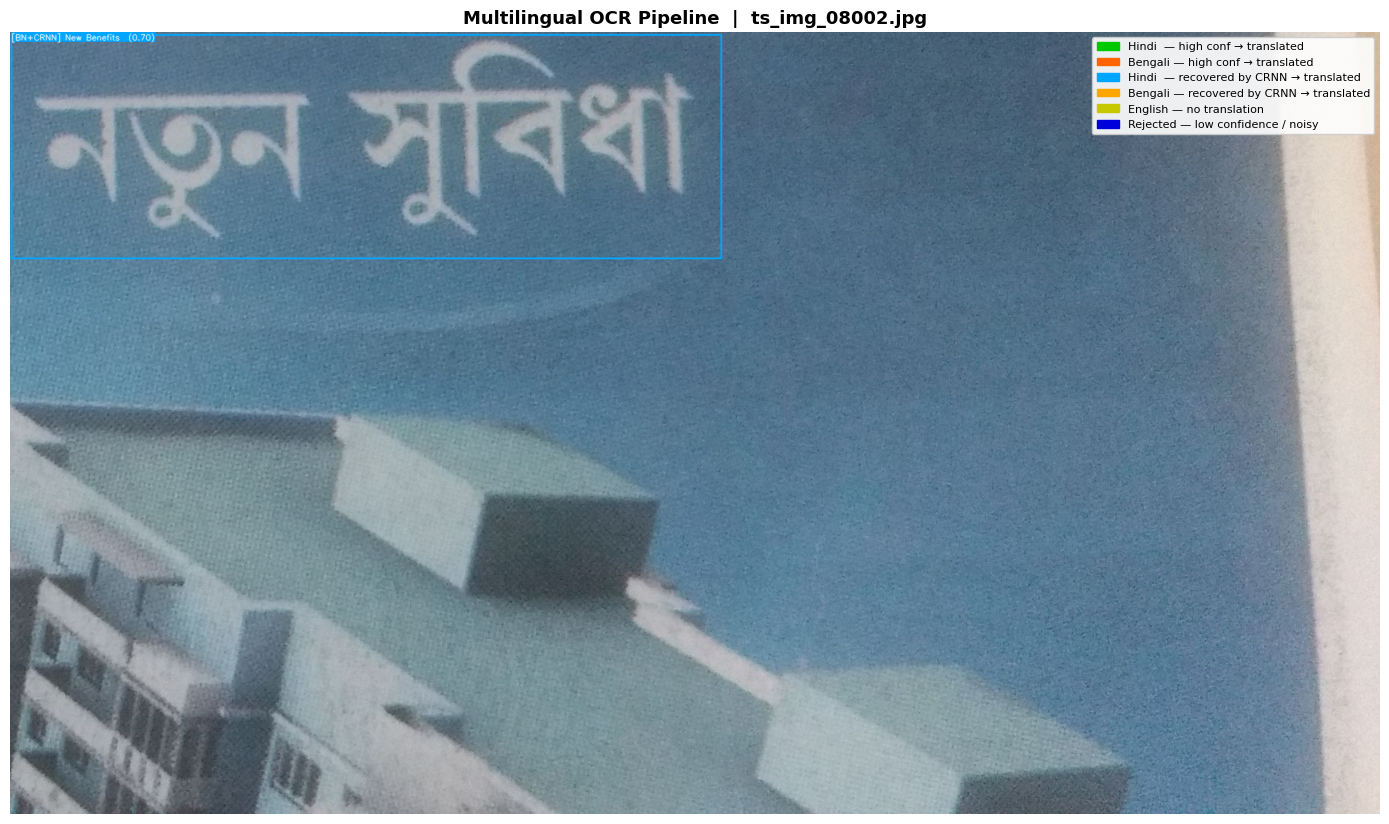


─────────────────────────────────────────────────────────────────────────────────────
  #    Lang   Conf  CRNN  OCR Text                  Translation
─────────────────────────────────────────────────────────────────────────────────────
  0      BN   0.70   YES  নতুন সুবিধা               New Benefits
─────────────────────────────────────────────────────────────────────────────────────
Total: 1 regions | Translated: 1 | CRNN used: 1 | Rejected/skipped: 0


In [9]:
image_path = "/kaggle/input/datasets/divyanshueopal/tistii/ts_img_08002.jpg"
draw_boxes(image_path)

Detected 7 text regions.


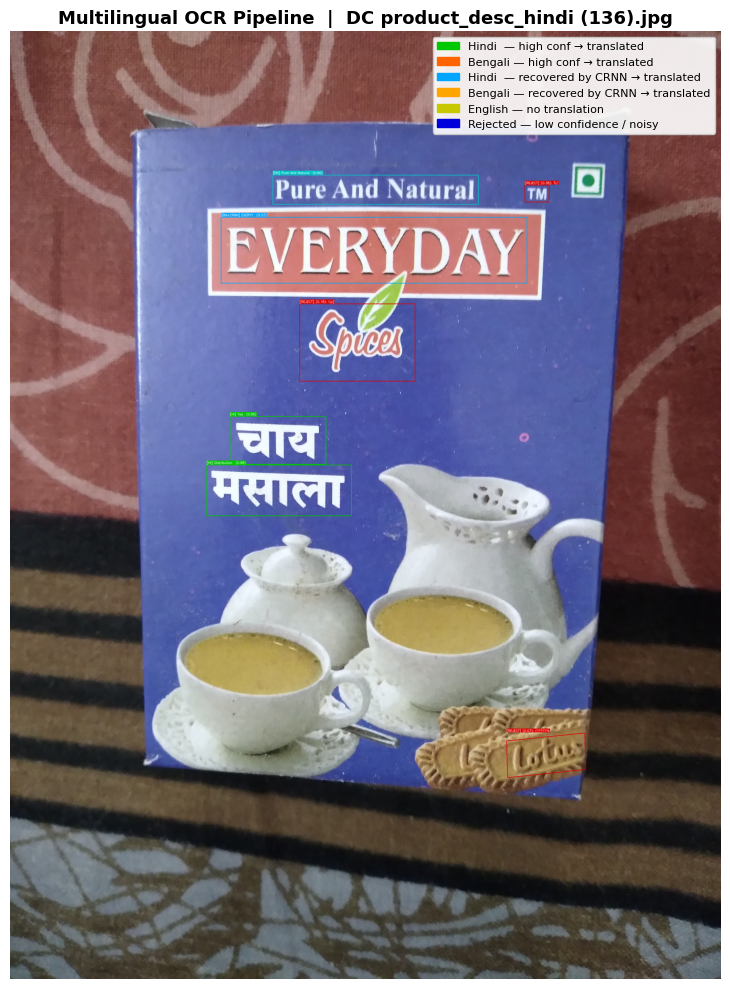


─────────────────────────────────────────────────────────────────────────────────────
  #    Lang   Conf  CRNN  OCR Text                  Translation
─────────────────────────────────────────────────────────────────────────────────────
  0      EN   0.90    no  Pure And Natural          Pure And Natural
  1      EN   0.38    no  TI/                       — (skipped)
  2      BN   0.57   YES  EVERYDAY                  EVERYY
  3      EN   0.18    no  Cp]                       — (skipped)
  4      HI   0.95    no  चाय                       Tea
  5      HI   0.98    no  मसाला                     Distribution
  6      HI   0.07    no  (४७k                      — (skipped)
─────────────────────────────────────────────────────────────────────────────────────
Total: 7 regions | Translated: 4 | CRNN used: 1 | Rejected/skipped: 3


In [10]:
image_path = "/kaggle/input/datasets/divyanshueopal/tistii/DC product_desc_hindi (136).jpg"
draw_boxes(image_path)

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output

text_input = widgets.Text(
    placeholder='Enter image path here...',
    layout=widgets.Layout(width='500px')
)
btn = widgets.Button(description='Run Pipeline', button_style='success')
out = widgets.Output()

def on_run(b):
    with out:
        clear_output()
        path = text_input.value.strip()
        if not path:
            print("Please enter an image path first.")
            return
        print(f"Running pipeline on: {path}")
        draw_boxes(path)

btn.on_click(on_run)
display(widgets.VBox([
    widgets.Label('Enter Image Path:'),
    text_input,
    btn,
    out
]))